In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving CMAPSSData.zip to CMAPSSData.zip


In [3]:
import zipfile
with zipfile.ZipFile('CMAPSSData.zip', 'r') as zip_ref:
    zip_ref.extractall('CMAPSSData')

In [4]:
import os
os.listdir('CMAPSSData')

['train_FD002.txt',
 'test_FD004.txt',
 'test_FD001.txt',
 'train_FD001.txt',
 'Damage Propagation Modeling.pdf',
 'RUL_FD004.txt',
 'RUL_FD001.txt',
 'RUL_FD002.txt',
 'train_FD004.txt',
 'train_FD003.txt',
 'test_FD003.txt',
 'RUL_FD003.txt',
 'test_FD002.txt',
 'readme.txt']

In [5]:
# Read the NASA dataset documentation using a compatible encoding
with open("CMAPSSData/readme.txt", "r", encoding="latin-1") as file:
    readme = file.read()

print(readme)

Data Set: FD001
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: ONE (HPC Degradation)

Data Set: FD002
Train trjectories: 260
Test trajectories: 259
Conditions: SIX 
Fault Modes: ONE (HPC Degradation)

Data Set: FD003
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: TWO (HPC Degradation, Fan Degradation)

Data Set: FD004
Train trjectories: 248
Test trajectories: 249
Conditions: SIX 
Fault Modes: TWO (HPC Degradation, Fan Degradation)



Experimental Scenario

Data sets consists of multiple multivariate time series. Each data set is further divided into training and test subsets. Each time series is from a different engine  i.e., the data can be considered to be from a fleet of engines of the same type. Each engine starts with different degrees of initial wear and manufacturing variation which is unknown to the user. This wear and variation is considered normal, i.e., it is not considered a fault condition. Th

In [6]:
# Load the FD001 training dataset
train_path = "CMAPSSData/train_FD001.txt"

train_raw = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)
train_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
# Define meaningful column names for the CMAPSS dataset
columns = (
   ["unit_id","cycle"] +
   [f"setting{i}" for i in range(1,4)] +
   [f"sensor{i}" for i in range(1,22)]
)
train_raw.columns = columns

train_raw.head()

,unit_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
# check the structure and data types of the training dataset
print("Dataset_shape:",train_raw.shape)
print("\nColumn names: ")
print(train_raw.columns.tolist())

print("\nData types:")
print(train_raw.dtypes)

Dataset_shape: (20631, 26)

Column names: 
['unit_id', 'cycle', 'setting1', 'setting2', 'setting3', 'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21']

Data types:
unit_id       int64
cycle         int64
setting1    float64
setting2    float64
setting3    float64
sensor1     float64
sensor2     float64
sensor3     float64
sensor4     float64
sensor5     float64
sensor6     float64
sensor7     float64
sensor8     float64
sensor9     float64
sensor10    float64
sensor11    float64
sensor12    float64
sensor13    float64
sensor14    float64
sensor15    float64
sensor16    float64
sensor17      int64
sensor18      int64
sensor19    float64
sensor20    float64
sensor21    float64
dtype: object


In [9]:
# check the number of engines and their operating cycle ranges
print("Number of engines: ", train_raw["unit_id"].nunique())

print("\nFirst ten engine IDs :")
print(train_raw["unit_id"].unique()[:10])

print("\nMaximum cycle for each of the first 10 engines: ")
print(
    train_raw.groupby("unit_id")["cycle"].max().head(10)

)


Number of engines:  100

First ten engine IDs :
[ 1  2  3  4  5  6  7  8  9 10]

Maximum cycle for each of the first 10 engines: 
unit_id
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64


In [10]:
# check for missing values in each column
missing_values = train_raw.isnull().sum()
print(missing_values)

unit_id     0
cycle       0
setting1    0
setting2    0
setting3    0
sensor1     0
sensor2     0
sensor3     0
sensor4     0
sensor5     0
sensor6     0
sensor7     0
sensor8     0
sensor9     0
sensor10    0
sensor11    0
sensor12    0
sensor13    0
sensor14    0
sensor15    0
sensor16    0
sensor17    0
sensor18    0
sensor19    0
sensor20    0
sensor21    0
dtype: int64


In [11]:
# check how much sensor varies across the training data
sensor_columns = [f"sensor{i}" for i in range(1,22)]
sensor_variance = train_raw[sensor_columns].var()
print(sensor_variance)


sensor1     4.273435e-21
sensor2     2.500533e-01
sensor3     3.759099e+01
sensor4     8.101089e+01
sensor5     1.152399e-23
sensor6     1.929279e-06
sensor7     7.833883e-01
sensor8     5.038938e-03
sensor9     4.876536e+02
sensor10    2.172333e-25
sensor11    7.133568e-02
sensor12    5.439850e-01
sensor13    5.172330e-03
sensor14    3.639005e+02
sensor15    1.406628e-03
sensor16    2.422479e-28
sensor17    2.398667e+00
sensor18    0.000000e+00
sensor19    0.000000e+00
sensor20    3.266927e-02
sensor21    1.171825e-02
dtype: float64


In [12]:
# Inspect the unique values of sensors with near-zero variance

constant_sensor_candidates = [
    "sensor1","sensor5","sensor10","sensor16","sensor18","sensor19"
]

for sensor in constant_sensor_candidates:
    print(f"{sensor}: {train_raw[sensor].unique()}")

sensor1: [518.67]
sensor5: [14.62]
sensor10: [1.3]
sensor16: [0.03]
sensor18: [2388]
sensor19: [100.]


In [13]:
# remove constant sensors that provide no variation in this dataset(FD001)

constant_sensors = [
    "sensor1","sensor5","sensor10","sensor16","sensor18","sensor19"
]
train_processed = train_raw.drop(columns=constant_sensors)

print("original shape: " ,train_raw.shape)
print("processed shape: ",train_processed.shape)


original shape:  (20631, 26)
processed shape:  (20631, 20)


In [14]:
# check for duplicate rows in processed dataset

duplicate_count = train_processed.duplicated().sum()
print("No of duplicate rows: " , duplicate_count)

No of duplicate rows:  0


In [15]:
# inspect the range of the remaining numerical features

feature_summary = train_processed.describe().T[["min","max","mean","std"]]

print(feature_summary)

                min        max         mean        std
unit_id      1.0000   100.0000    51.506568  29.227633
cycle        1.0000   362.0000   108.807862  68.880990
setting1    -0.0087     0.0087    -0.000009   0.002187
setting2    -0.0006     0.0006     0.000002   0.000293
setting3   100.0000   100.0000   100.000000   0.000000
sensor2    641.2100   644.5300   642.680934   0.500053
sensor3   1571.0400  1616.9100  1590.523119   6.131150
sensor4   1382.2500  1441.4900  1408.933782   9.000605
sensor6     21.6000    21.6100    21.609803   0.001389
sensor7    549.8500   556.0600   553.367711   0.885092
sensor8   2387.9000  2388.5600  2388.096652   0.070985
sensor9   9021.7300  9244.5900  9065.242941  22.082880
sensor11    46.8500    48.5300    47.541168   0.267087
sensor12   518.6900   523.3800   521.413470   0.737553
sensor13  2387.8800  2388.5600  2388.096152   0.071919
sensor14  8099.9400  8293.7200  8143.752722  19.076176
sensor15     8.3249     8.5848     8.442146   0.037505
sensor17  

In [16]:
# remove the constant operating setting from the processed dataset

train_processed = train_processed.drop(columns = ["setting3"])
print("processed shape: ", train_processed.shape)

processed shape:  (20631, 19)


In [17]:
# inspect the distributions of remaining numerical features

train_processed.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_id,20631.0,51.506568,29.227633,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,68.880990,1.0000,52.0000,104.0000,156.0000,362.0000
setting1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0000,0.0003,0.0006
sensor2,20631.0,642.680934,0.500053,641.2100,642.3250,642.6400,643.0000,644.5300
sensor3,20631.0,1590.523119,6.131150,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor4,20631.0,1408.933782,9.000605,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor6,20631.0,21.609803,0.001389,21.6000,21.6100,21.6100,21.6100,21.6100
sensor7,20631.0,553.367711,0.885092,549.8500,552.8100,553.4400,554.0100,556.0600
sensor8,20631.0,2388.096652,0.070985,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600


In [18]:
# identify potential outliers using IQR method

feature_columns = [
    col for col in train_processed.columns
    if col not in ["unit_id", "cycle"]
]

Q1 = train_processed[feature_columns].quantile(0.25)
Q3 = train_processed[feature_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (train_processed[feature_columns] < lower_bound)|
    (train_processed[feature_columns] > upper_bound)
).sum()

print("Potential outlier counts:")
print(outlier_counts)

Potential outlier counts:
setting1     105
setting2       0
sensor2      128
sensor3      165
sensor4      120
sensor6      406
sensor7      110
sensor8      320
sensor9     1686
sensor11     167
sensor12     146
sensor13     161
sensor14    1543
sensor15     120
sensor17      81
sensor20     117
sensor21     136
dtype: int64


In [19]:
# calculate the maximum operating cycle for each engine

max_cycle_per_engine = (train_processed.groupby("unit_id")["cycle"].max()
)
print(max_cycle_per_engine)


unit_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64


In [78]:
# Calculate Remaining Useful Life (RUL) for each observation


max_cycle_per_engine = (
    train_processed.groupby("unit_id")["cycle"].max()
)

train_processed["RUL_raw"] = (
    train_processed["unit_id"].map(max_cycle_per_engine)
    - train_processed["cycle"]
)

RUL_CAP = 125

train_processed["RUL"] = (
    train_processed["RUL_raw"].clip(upper=RUL_CAP)
)

print("RUL cap:", RUL_CAP)
print("Raw RUL maximum:", train_processed["RUL_raw"].max())
print("Capped RUL maximum:", train_processed["RUL"].max())

display(
    train_processed[
        ["unit_id", "cycle", "RUL_raw", "RUL"]
    ].head(10)
)


RUL cap: 125
Raw RUL maximum: 361
Capped RUL maximum: 125


,unit_id,cycle,RUL_raw,RUL
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


In [21]:
# calculate a five cycle rolling mean for sensor3 within each engine

train_processed["sensor3_rolling_mean"] = (
    train_processed.groupby("unit_id")["sensor3"].transform
    (lambda x : x.rolling(window=5, min_periods=1).mean())
)

train_processed[
    ["unit_id","cycle","sensor3_rolling_mean"]
].head(10)

,unit_id,cycle,sensor3_rolling_mean
0,1,1,1589.700000
1,1,2,1590.760000
2,1,3,1589.836667
3,1,4,1588.075000
4,1,5,1587.030000
5,1,6,1585.984000
6,1,7,1586.084000
7,1,8,1585.078000
8,1,9,1586.716000
9,1,10,1588.394000


In [22]:
# Verify that the rolling feature was added successfully

print("New feature:", "sensor3_rolling_mean" in train_processed.columns)
print("Number of columns:", len(train_processed.columns))

New feature: True
Number of columns: 22


In [23]:
def add_rolling_mean_features(df,sensor_columns,window = 5):

    df = df.copy()

    for sensor in sensor_columns:
        feature_name = f"{sensor}_rolling_mean"

        df[feature_name] = (
            df.groupby("unit_id")[sensor].transform(
                lambda x : x.rolling(
                    window=window,
                    min_periods=1
                ).mean()
            )
        )
    return df

In [24]:
# Select the sensors that remain after constabt feature removal

sensor_columns = [
    col for col in train_processed.columns
    if col.startswith("sensor") and not col.endswith("rolling_mean")
]

print(sensor_columns)

['sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


In [25]:
# Generate 5-cycle rolling mean features for all varying sensors

trained_processed = add_rolling_mean_features(
    train_processed,
    sensor_columns,
    window = 5

)
print("updated shape: ",trained_processed.shape)

updated shape:  (20631, 36)


In [26]:
# identify all rolling mean features that were created

rolling_mean_columns = [
    col for col in trained_processed.columns
    if col.endswith("_rolling_mean")
]

print("Number of rolling mesn features: " ,len(rolling_mean_columns))
print("\nRolling-mean features: ")
print(rolling_mean_columns)

Number of rolling mesn features:  15

Rolling-mean features: 
['sensor3_rolling_mean', 'sensor2_rolling_mean', 'sensor4_rolling_mean', 'sensor6_rolling_mean', 'sensor7_rolling_mean', 'sensor8_rolling_mean', 'sensor9_rolling_mean', 'sensor11_rolling_mean', 'sensor12_rolling_mean', 'sensor13_rolling_mean', 'sensor14_rolling_mean', 'sensor15_rolling_mean', 'sensor17_rolling_mean', 'sensor20_rolling_mean', 'sensor21_rolling_mean']


In [27]:
def add_rolling_std_features(df,sensor_columns,window = 5):

    df = df.copy()

    for sensor in sensor_columns:
        feature_name = f"{sensor}_rolling_std"

        df[feature_name] = (
            df.groupby("unit_id")[sensor]
            .transform(lambda x : x.rolling(
                window=window,
                min_periods=1
            ).std()

          )

        )
    return df

In [28]:
# Generate 5-cycle rolling standard deviation features

train_processed = add_rolling_std_features(
    train_processed,
    sensor_columns,
    window=5
)

print("Updated shape:", train_processed.shape)

Updated shape: (20631, 37)


In [29]:
# Check which sensors are currently stored in sensor_columns

print("Number of sensors:", len(sensor_columns))
print("Sensors:", sensor_columns)

Number of sensors: 15
Sensors: ['sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


In [30]:
# Check which rolling-standard-deviation features currently exist

rolling_std_columns = [
    col for col in train_processed.columns
    if col.endswith("_rolling_std")
]

print("Number of rolling-std features:", len(rolling_std_columns))
print("\nRolling-std features:")
print(rolling_std_columns)

Number of rolling-std features: 15

Rolling-std features:
['sensor2_rolling_std', 'sensor3_rolling_std', 'sensor4_rolling_std', 'sensor6_rolling_std', 'sensor7_rolling_std', 'sensor8_rolling_std', 'sensor9_rolling_std', 'sensor11_rolling_std', 'sensor12_rolling_std', 'sensor13_rolling_std', 'sensor14_rolling_std', 'sensor15_rolling_std', 'sensor17_rolling_std', 'sensor20_rolling_std', 'sensor21_rolling_std']


In [31]:
print("Current dataset shape:", train_processed.shape)

print("\nOriginal + target columns:")
print([
    col for col in train_processed.columns
    if not col.endswith("_rolling_mean")
    and not col.endswith("_rolling_std")
])

Current dataset shape: (20631, 37)

Original + target columns:
['unit_id', 'cycle', 'setting1', 'setting2', 'sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21', 'RUL_raw', 'RUL']


In [32]:
# Count each type of column currently in the dataset

base_columns = [
    col for col in train_processed.columns
    if not col.endswith("_rolling_mean")
    and not col.endswith("_rolling_std")
]

rolling_mean_columns = [
    col for col in train_processed.columns
    if col.endswith("_rolling_mean")
]

rolling_std_columns = [
    col for col in train_processed.columns
    if col.endswith("_rolling_std")
]

print("Base columns:", len(base_columns))
print("Rolling mean columns:", len(rolling_mean_columns))
print("Rolling std columns:", len(rolling_std_columns))

print("\nTotal according to categories:",
      len(base_columns) + len(rolling_mean_columns) + len(rolling_std_columns))

print("\nActual DataFrame columns:", len(train_processed.columns))

Base columns: 21
Rolling mean columns: 1
Rolling std columns: 15

Total according to categories: 37

Actual DataFrame columns: 37


In [33]:
# Add any missing rolling-mean features

for sensor in sensor_columns:
    feature_name = f"{sensor}_rolling_mean"

    if feature_name not in train_processed.columns:
        train_processed[feature_name] = (
            train_processed
            .groupby("unit_id")[sensor]
            .transform(
                lambda x: x.rolling(
                    window=5,
                    min_periods=1
                ).mean()
            )
        )

print("Dataset shape after fixing rolling means:", train_processed.shape)

Dataset shape after fixing rolling means: (20631, 51)


In [34]:
# Final verification of engineered feature groups

base_columns = [
    col for col in train_processed.columns
    if not col.endswith("_rolling_mean")
    and not col.endswith("_rolling_std")
]

rolling_mean_columns = [
    col for col in train_processed.columns
    if col.endswith("_rolling_mean")
]

rolling_std_columns = [
    col for col in train_processed.columns
    if col.endswith("_rolling_std")
]

print("Base columns:", len(base_columns))
print("Rolling mean features:", len(rolling_mean_columns))
print("Rolling std features:", len(rolling_std_columns))
print("Total columns:", len(train_processed.columns))

Base columns: 21
Rolling mean features: 15
Rolling std features: 15
Total columns: 51


In [35]:
# Check missing values in rolling standard deviation features

rolling_std_missing = train_processed[rolling_std_columns].isnull().sum()

print("Missing values in rolling-std features:")
print(rolling_std_missing)

print("\nTotal missing values:", rolling_std_missing.sum())

Missing values in rolling-std features:
sensor2_rolling_std     100
sensor3_rolling_std     100
sensor4_rolling_std     100
sensor6_rolling_std     100
sensor7_rolling_std     100
sensor8_rolling_std     100
sensor9_rolling_std     100
sensor11_rolling_std    100
sensor12_rolling_std    100
sensor13_rolling_std    100
sensor14_rolling_std    100
sensor15_rolling_std    100
sensor17_rolling_std    100
sensor20_rolling_std    100
sensor21_rolling_std    100
dtype: int64

Total missing values: 1500


In [36]:
# Fill initial rolling-standard-deviation NaN values with 0

train_processed[rolling_std_columns] = (
    train_processed[rolling_std_columns].fillna(0)
)

print(
    "Remaining missing values in rolling-std features:",
    train_processed[rolling_std_columns].isnull().sum().sum()
)

Remaining missing values in rolling-std features: 0


In [37]:
# Calculate the cycle-to-cycle change for sensor3

train_processed["sensor3_rate_of_change"] = (
    train_processed
    .groupby("unit_id")["sensor3"]
    .diff()
)

train_processed[
    ["unit_id", "cycle", "sensor3", "sensor3_rate_of_change"]
].head(10)

,unit_id,cycle,sensor3,sensor3_rate_of_change
0,1,1,1589.70,NaN
1,1,2,1591.82,2.12
2,1,3,1587.99,-3.83
3,1,4,1582.79,-5.20
4,1,5,1582.85,0.06
5,1,6,1584.47,1.62
6,1,7,1592.32,7.85
7,1,8,1582.96,-9.36
8,1,9,1590.98,8.02
9,1,10,1591.24,0.26


In [38]:
def add_rate_of_change_features(df, sensor_columns):

   df = df.copy()

   for sensor in sensor_columns:
        feature_name = f"{sensor}_rate_of_change"

        df[feature_name] = (
            df.groupby("unit_id")[sensor]
            .diff()
        )

   return df

In [39]:
# Generate rate-of-change features for all varying sensors

train_processed = add_rate_of_change_features(
    train_processed,
    sensor_columns
)

print("Updated shape:", train_processed.shape)

Updated shape: (20631, 66)


In [40]:
# Verify all rate-of-change features

rate_of_change_columns = [
    col for col in train_processed.columns
    if col.endswith("_rate_of_change")
]

print("Number of rate-of-change features:", len(rate_of_change_columns))
print("\nRate-of-change features:")
print(rate_of_change_columns)

Number of rate-of-change features: 15

Rate-of-change features:
['sensor3_rate_of_change', 'sensor2_rate_of_change', 'sensor4_rate_of_change', 'sensor6_rate_of_change', 'sensor7_rate_of_change', 'sensor8_rate_of_change', 'sensor9_rate_of_change', 'sensor11_rate_of_change', 'sensor12_rate_of_change', 'sensor13_rate_of_change', 'sensor14_rate_of_change', 'sensor15_rate_of_change', 'sensor17_rate_of_change', 'sensor20_rate_of_change', 'sensor21_rate_of_change']


In [41]:
# Check missing values in rate-of-change features

rate_of_change_missing = (
    train_processed[rate_of_change_columns]
    .isnull()
    .sum()
)

print("Missing values in rate-of-change features:")
print(rate_of_change_missing)

print("\nTotal missing values:", rate_of_change_missing.sum())

Missing values in rate-of-change features:
sensor3_rate_of_change     100
sensor2_rate_of_change     100
sensor4_rate_of_change     100
sensor6_rate_of_change     100
sensor7_rate_of_change     100
sensor8_rate_of_change     100
sensor9_rate_of_change     100
sensor11_rate_of_change    100
sensor12_rate_of_change    100
sensor13_rate_of_change    100
sensor14_rate_of_change    100
sensor15_rate_of_change    100
sensor17_rate_of_change    100
sensor20_rate_of_change    100
sensor21_rate_of_change    100
dtype: int64

Total missing values: 1500


In [42]:
# Fill initial rate-of-change NaN values with 0

train_processed[rate_of_change_columns] = (
    train_processed[rate_of_change_columns].fillna(0)
)

print(
    "Remaining missing values in rate-of-change features:",
    train_processed[rate_of_change_columns].isnull().sum().sum()
)

Remaining missing values in rate-of-change features: 0


In [43]:
# Perform a complete missing-value audit

missing_values = train_processed.isnull().sum()

print("Total missing values in dataset:", missing_values.sum())

print("\nColumns containing missing values:")
print(missing_values[missing_values > 0])

Total missing values in dataset: 0

Columns containing missing values:
Series([], dtype: int64)


In [44]:
from sklearn.model_selection import train_test_split

# Get all unique engine IDs
engine_ids = train_processed["unit_id"].unique()

# Split engines into development and final holdout sets
development_engines, holdout_engines = train_test_split(
    engine_ids,
    test_size=0.20,
    random_state=42
)

print("Number of development engines:", len(development_engines))
print("Number of holdout engines:", len(holdout_engines))

print("\nDevelopment engine IDs:")
print(sorted(development_engines))

print("\nHoldout engine IDs:")
print(sorted(holdout_engines))

Number of development engines: 80
Number of holdout engines: 20

Development engine IDs:
[np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(72), np.int64(73), np.int64(75), np.int64(76), np.int64(79), np.int64(80), np.int64(82), np.int64(83), np.int6

In [45]:
# Verify that development and holdout engines do not overlap

overlap = set(development_engines) & set(holdout_engines)

print("Number of overlapping engines:", len(overlap))
print("Overlapping engine IDs:", overlap)

Number of overlapping engines: 0
Overlapping engine IDs: set()


In [46]:
# Create development and holdout datasets using engine IDs

development_data = train_processed[
    train_processed["unit_id"].isin(development_engines)
].copy()

holdout_data = train_processed[
    train_processed["unit_id"].isin(holdout_engines)
].copy()

print("Development data shape:", development_data.shape)
print("Holdout data shape:", holdout_data.shape)

print("\nDevelopment engines:", development_data["unit_id"].nunique())
print("Holdout engines:", holdout_data["unit_id"].nunique())

Development data shape: (16561, 66)
Holdout data shape: (4070, 66)

Development engines: 80
Holdout engines: 20


In [47]:
# Sort development engines to preserve their temporal ordering

development_engines_sorted = sorted(development_engines)

print("Number of development engines:", len(development_engines_sorted))

print("\nFirst 10 development engines:")
print(development_engines_sorted[:10])

print("\nLast 10 development engines:")
print(development_engines_sorted[-10:])

Number of development engines: 80

First 10 development engines:
[np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14)]

Last 10 development engines:
[np.int64(90), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(99), np.int64(100)]


In [48]:
# Define expanding-window validation folds

temporal_folds = []

train_sizes = [48, 56, 64, 72]
validation_size = 8

for train_size in train_sizes:
    train_engines = development_engines_sorted[:train_size]

    validation_start = train_size
    validation_end = train_size + validation_size

    validation_engines = development_engines_sorted[
        validation_start:validation_end
    ]

    temporal_folds.append({
        "train_engines": train_engines,
        "validation_engines": validation_engines
    })

print("Number of temporal folds:", len(temporal_folds))

for i, fold in enumerate(temporal_folds, start=1):
    print(f"\nFold {i}")
    print("Training engines:", len(fold["train_engines"]))
    print("Validation engines:", len(fold["validation_engines"]))
    print(
        "Training range:",
        fold["train_engines"][0],
        "to",
        fold["train_engines"][-1]
    )
    print(
        "Validation range:",
        fold["validation_engines"][0],
        "to",
        fold["validation_engines"][-1]
    )

Number of temporal folds: 4

Fold 1
Training engines: 48
Validation engines: 8
Training range: 2 to 61
Validation range: 62 to 69

Fold 2
Training engines: 56
Validation engines: 8
Training range: 2 to 69
Validation range: 70 to 82

Fold 3
Training engines: 64
Validation engines: 8
Training range: 2 to 82
Validation range: 83 to 92

Fold 4
Training engines: 72
Validation engines: 8
Training range: 2 to 92
Validation range: 93 to 100


In [49]:
# Verify that each temporal fold is correctly structured

for i, fold in enumerate(temporal_folds, start=1):

    train_set = set(fold["train_engines"])
    validation_set = set(fold["validation_engines"])

    overlap = train_set & validation_set

    print(f"\nFold {i}")
    print("Training engines:", len(train_set))
    print("Validation engines:", len(validation_set))
    print("Train/validation overlap:", len(overlap))


Fold 1
Training engines: 48
Validation engines: 8
Train/validation overlap: 0

Fold 2
Training engines: 56
Validation engines: 8
Train/validation overlap: 0

Fold 3
Training engines: 64
Validation engines: 8
Train/validation overlap: 0

Fold 4
Training engines: 72
Validation engines: 8
Train/validation overlap: 0


In [50]:
# Define feature columns and target column

target_column = "RUL"

# Exclude engine identity and the target.
# Keep cycle because it represents the engine's operating age.
feature_columns = [
    col for col in train_processed.columns
    if col not in ["unit_id", target_column, "RUL_raw"]
]

X_development = development_data[feature_columns].copy()
y_development = development_data[target_column].copy()

X_holdout = holdout_data[feature_columns].copy()
y_holdout = holdout_data[target_column].copy()

print("Number of features:", len(feature_columns))

print("\nFeature columns:")
print(feature_columns)

print("\nDevelopment X shape:", X_development.shape)
print("Development y shape:", y_development.shape)

print("\nHoldout X shape:", X_holdout.shape)
print("Holdout y shape:", y_holdout.shape)

Number of features: 63

Feature columns:
['cycle', 'setting1', 'setting2', 'sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21', 'sensor3_rolling_mean', 'sensor2_rolling_std', 'sensor3_rolling_std', 'sensor4_rolling_std', 'sensor6_rolling_std', 'sensor7_rolling_std', 'sensor8_rolling_std', 'sensor9_rolling_std', 'sensor11_rolling_std', 'sensor12_rolling_std', 'sensor13_rolling_std', 'sensor14_rolling_std', 'sensor15_rolling_std', 'sensor17_rolling_std', 'sensor20_rolling_std', 'sensor21_rolling_std', 'sensor2_rolling_mean', 'sensor4_rolling_mean', 'sensor6_rolling_mean', 'sensor7_rolling_mean', 'sensor8_rolling_mean', 'sensor9_rolling_mean', 'sensor11_rolling_mean', 'sensor12_rolling_mean', 'sensor13_rolling_mean', 'sensor14_rolling_mean', 'sensor15_rolling_mean', 'sensor17_rolling_mean', 'sensor20_rolling_mean', 'sensor21_rolling_mean', 'sensor3_rate_of_change', 'sens

In [51]:
# OFFICIAL NASA CMAPSS FD001 TEST SET

test_path = "CMAPSSData/test_FD001.txt"
rul_path = "CMAPSSData/RUL_FD001.txt"

test_raw = pd.read_csv(
    test_path,
    sep=r"\s+",
    header=None
)

test_raw.columns = columns

# Ground-truth RUL_FD001 contains the RUL at the LAST observed
# cycle of each test engine.
official_rul = pd.read_csv(
    rul_path,
    sep=r"\s+",
    header=None,
    names=["RUL_at_last_cycle"]
)

print("Official test shape:", test_raw.shape)
print("Official test engines:", test_raw["unit_id"].nunique())
print("Official RUL entries:", len(official_rul))

if test_raw["unit_id"].nunique() != len(official_rul):
    raise ValueError(
        "The number of test engines does not match RUL_FD001.txt."
    )


Official test shape: (13096, 26)
Official test engines: 100
Official RUL entries: 100


In [52]:
# APPLY THE SAME FEATURE ENGINEERING TO THE OFFICIAL TEST SET

test_processed = test_raw.drop(
    columns=constant_sensors
).copy()

test_processed = test_processed.drop(
    columns=["setting3"]
)

# Sort by engine and cycle before creating temporal features.
test_processed = test_processed.sort_values(
    ["unit_id", "cycle"]
).reset_index(drop=True)

# Use the SAME sensor list and feature-engineering functions
# that were used for the training data.
test_processed = add_rolling_mean_features(
    test_processed,
    sensor_columns,
    window=5
)

test_processed = add_rolling_std_features(
    test_processed,
    sensor_columns,
    window=5
)

test_processed = add_rate_of_change_features(
    test_processed,
    sensor_columns
)

# Match the training-data handling for initial rolling statistics.
rolling_std_columns_test = [
    col for col in test_processed.columns
    if col.endswith("_rolling_std")
]

rate_of_change_columns_test = [
    col for col in test_processed.columns
    if col.endswith("_rate_of_change")
]

test_processed[rolling_std_columns_test] = (
    test_processed[rolling_std_columns_test].fillna(0)
)

test_processed[rate_of_change_columns_test] = (
    test_processed[rate_of_change_columns_test].fillna(0)
)

print("Processed official test shape:", test_processed.shape)
print("Missing values:", test_processed.isnull().sum().sum())


Processed official test shape: (13096, 64)
Missing values: 0


In [53]:
# RECONSTRUCT OFFICIAL TEST RUL

test_last_cycle = (
    test_processed.groupby("unit_id")["cycle"].transform("max")
)

# RUL_FD001.txt is ordered by test engine ID (1..N).
final_rul_map = {
    engine_id: rul
    for engine_id, rul in zip(
        sorted(test_processed["unit_id"].unique()),
        official_rul["RUL_at_last_cycle"].to_numpy()
    )
}

test_processed["RUL_raw"] = (
    test_processed["unit_id"].map(final_rul_map)
    + test_last_cycle
    - test_processed["cycle"]
)

if test_processed["RUL_raw"].isnull().any():
    raise ValueError(
        "Some test engines could not be matched to RUL_FD001.txt."
    )

test_processed["RUL"] = (
    test_processed["RUL_raw"].clip(upper=RUL_CAP)
)

print("Official test raw RUL range:",
      test_processed["RUL_raw"].min(),
      "to",
      test_processed["RUL_raw"].max())

print("Official test capped RUL range:",
      test_processed["RUL"].min(),
      "to",
      test_processed["RUL"].max())

display(
    test_processed[
        ["unit_id", "cycle", "RUL_raw", "RUL"]
    ].head(10)
)


Official test raw RUL range: 7 to 340
Official test capped RUL range: 7 to 125


,unit_id,cycle,RUL_raw,RUL
0,1,1,142,125
1,1,2,141,125
2,1,3,140,125
3,1,4,139,125
4,1,5,138,125
5,1,6,137,125
6,1,7,136,125
7,1,8,135,125
8,1,9,134,125
9,1,10,133,125


In [54]:
# FINAL OFFICIAL TEST FEATURES / TARGET

missing_test_features = [
    col for col in feature_columns
    if col not in test_processed.columns
]

if missing_test_features:
    raise ValueError(
        f"Missing test features: {missing_test_features}"
    )

X_official_test = test_processed[
    feature_columns
].copy()

y_official_test = test_processed[
    target_column
].copy()

# Keep the uncapped target separately for transparent reporting.
y_official_test_raw = test_processed[
    "RUL_raw"
].copy()

print("Official test X shape:", X_official_test.shape)
print("Official test y shape:", y_official_test.shape)
print("Feature count:", len(feature_columns))

print(
    "Feature-column order matches training:",
    list(X_official_test.columns) == list(X_development.columns)
)


Official test X shape: (13096, 63)
Official test y shape: (13096,)
Feature count: 63
Feature-column order matches training: True


In [55]:
from sklearn.preprocessing import StandardScaler

# Get the first temporal validation fold
fold_1 = temporal_folds[0]

fold_1_train_engines = fold_1["train_engines"]
fold_1_validation_engines = fold_1["validation_engines"]

# Create Fold 1 datasets
fold_1_train = development_data[
    development_data["unit_id"].isin(fold_1_train_engines)
].copy()

fold_1_validation = development_data[
    development_data["unit_id"].isin(fold_1_validation_engines)
].copy()

# Separate features and target
X_fold_1_train = fold_1_train[feature_columns]
y_fold_1_train = fold_1_train[target_column]

X_fold_1_validation = fold_1_validation[feature_columns]
y_fold_1_validation = fold_1_validation[target_column]

print("Fold 1 training shape:", X_fold_1_train.shape)
print("Fold 1 validation shape:", X_fold_1_validation.shape)

print("\nFold 1 training engines:", fold_1_train["unit_id"].nunique())
print("Fold 1 validation engines:", fold_1_validation["unit_id"].nunique())

Fold 1 training shape: (9458, 63)
Fold 1 validation shape: (1866, 63)

Fold 1 training engines: 48
Fold 1 validation engines: 8


In [56]:
# Create and fit the scaler using ONLY Fold 1 training data

scaler_fold_1 = StandardScaler()

X_fold_1_train_scaled = scaler_fold_1.fit_transform(
    X_fold_1_train
)

X_fold_1_validation_scaled = scaler_fold_1.transform(
    X_fold_1_validation
)

print("Scaled training shape:", X_fold_1_train_scaled.shape)
print("Scaled validation shape:", X_fold_1_validation_scaled.shape)

Scaled training shape: (9458, 63)
Scaled validation shape: (1866, 63)


In [57]:
# Verify scaling using the training data

train_scaled_mean = X_fold_1_train_scaled.mean(axis=0)
train_scaled_std = X_fold_1_train_scaled.std(axis=0)

print("Maximum absolute training mean:")
print(abs(train_scaled_mean).max())

print("\nMaximum difference from unit standard deviation:")
print(abs(train_scaled_std - 1).max())

Maximum absolute training mean:
1.0380512501827443e-11

Maximum difference from unit standard deviation:
3.3306690738754696e-16


In [58]:
# Check the distribution of the validation data after
# applying the training-fitted scaler

validation_scaled_mean = X_fold_1_validation_scaled.mean(axis=0)
validation_scaled_std = X_fold_1_validation_scaled.std(axis=0)

print("Maximum absolute validation mean:")
print(abs(validation_scaled_mean).max())

print("\nValidation mean across all features:")
print(validation_scaled_mean.mean())

print("\nAverage validation standard deviation:")
print(validation_scaled_std.mean())

Maximum absolute validation mean:
0.4188885591288724

Validation mean across all features:
0.03379462909576034

Average validation standard deviation:
0.913404519310786


In [59]:
# Verify that the RUL target remains in its original scale

print("RUL training minimum:", y_fold_1_train.min())
print("RUL training maximum:", y_fold_1_train.max())

print("\nRUL validation minimum:", y_fold_1_validation.min())
print("RUL validation maximum:", y_fold_1_validation.max())

print("\nNumber of training targets:", len(y_fold_1_train))
print("Number of validation targets:", len(y_fold_1_validation))

RUL training minimum: 0
RUL training maximum: 125

RUL validation minimum: 0
RUL validation maximum: 125

Number of training targets: 9458
Number of validation targets: 1866


In [60]:
import numpy as np

# Check for NaN and infinite values after scaling

print("NaN values in scaled training data:",
      np.isnan(X_fold_1_train_scaled).sum())

print("NaN values in scaled validation data:",
      np.isnan(X_fold_1_validation_scaled).sum())

print("\nInfinite values in scaled training data:",
      np.isinf(X_fold_1_train_scaled).sum())

print("Infinite values in scaled validation data:",
      np.isinf(X_fold_1_validation_scaled).sum())

NaN values in scaled training data: 0
NaN values in scaled validation data: 0

Infinite values in scaled training data: 0
Infinite values in scaled validation data: 0


In [61]:
def prepare_temporal_fold(
    development_data,
    fold,
    feature_columns,
    target_column
):


    # Extract engine IDs for this fold
    train_engines = fold["train_engines"]
    validation_engines = fold["validation_engines"]

    # Select complete engine trajectories
    train_data = development_data[
        development_data["unit_id"].isin(train_engines)
    ].copy()

    validation_data = development_data[
        development_data["unit_id"].isin(validation_engines)
    ].copy()

    # Separate features and target
    X_train = train_data[feature_columns]
    y_train = train_data[target_column]

    X_validation = validation_data[feature_columns]
    y_validation = validation_data[target_column]

    # Create scaler
    scaler = StandardScaler()

    # IMPORTANT:
    # Fit only on training data to prevent validation leakage.
    X_train_scaled = scaler.fit_transform(X_train)

    # Use the same fitted scaler for validation data.
    X_validation_scaled = scaler.transform(X_validation)

    return {
        "X_train": X_train_scaled,
        "y_train": y_train,
        "X_validation": X_validation_scaled,
        "y_validation": y_validation,
        "scaler": scaler,
        "train_engines": train_engines,
        "validation_engines": validation_engines
    }

In [62]:
# Prepare all temporal validation folds

prepared_folds = []

for fold_number, fold in enumerate(temporal_folds, start=1):

    prepared_fold = prepare_temporal_fold(
        development_data=development_data,
        fold=fold,
        feature_columns=feature_columns,
        target_column=target_column
    )

    prepared_folds.append(prepared_fold)

    print(f"Fold {fold_number}")
    print(
        "  Training shape:",
        prepared_fold["X_train"].shape
    )
    print(
        "  Validation shape:",
        prepared_fold["X_validation"].shape
    )
    print(
        "  Training engines:",
        len(prepared_fold["train_engines"])
    )
    print(
        "  Validation engines:",
        len(prepared_fold["validation_engines"])
    )
    print()

Fold 1
  Training shape: (9458, 63)
  Validation shape: (1866, 63)
  Training engines: 48
  Validation engines: 8

Fold 2
  Training shape: (11324, 63)
  Validation shape: (1600, 63)
  Training engines: 56
  Validation engines: 8

Fold 3
  Training shape: (12924, 63)
  Validation shape: (1862, 63)
  Training engines: 64
  Validation engines: 8

Fold 4
  Training shape: (14786, 63)
  Validation shape: (1775, 63)
  Training engines: 72
  Validation engines: 8



In [63]:
# Validate the prepared temporal folds

for i, fold in enumerate(prepared_folds, start=1):

    X_train = fold["X_train"]
    X_validation = fold["X_validation"]

    train_nan = np.isnan(X_train).sum()
    validation_nan = np.isnan(X_validation).sum()

    train_inf = np.isinf(X_train).sum()
    validation_inf = np.isinf(X_validation).sum()

    overlap = (
        set(fold["train_engines"])
        & set(fold["validation_engines"])
    )

    print(f"Fold {i}")
    print("  Train features:", X_train.shape[1])
    print("  Validation features:", X_validation.shape[1])
    print("  Train NaNs:", train_nan)
    print("  Validation NaNs:", validation_nan)
    print("  Train infinities:", train_inf)
    print("  Validation infinities:", validation_inf)
    print("  Engine overlap:", len(overlap))
    print()

Fold 1
  Train features: 63
  Validation features: 63
  Train NaNs: 0
  Validation NaNs: 0
  Train infinities: 0
  Validation infinities: 0
  Engine overlap: 0

Fold 2
  Train features: 63
  Validation features: 63
  Train NaNs: 0
  Validation NaNs: 0
  Train infinities: 0
  Validation infinities: 0
  Engine overlap: 0

Fold 3
  Train features: 63
  Validation features: 63
  Train NaNs: 0
  Validation NaNs: 0
  Train infinities: 0
  Validation infinities: 0
  Engine overlap: 0

Fold 4
  Train features: 63
  Validation features: 63
  Train NaNs: 0
  Validation NaNs: 0
  Train infinities: 0
  Validation infinities: 0
  Engine overlap: 0



In [64]:
from sklearn.ensemble import RandomForestRegressor

# Create the baseline Random Forest model

baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Baseline model:")
print(baseline_model)

Baseline model:
RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)


In [65]:
# Train the baseline Random Forest on Fold 1

baseline_model.fit(
    prepared_folds[0]["X_train"],
    prepared_folds[0]["y_train"]
)

print("Fold 1 baseline model training completed.")

Fold 1 baseline model training completed.


In [66]:
# Generate RUL predictions for the Fold 1 validation data

y_fold_1_pred = baseline_model.predict(
    prepared_folds[0]["X_validation"]
)

print("Number of predictions:", len(y_fold_1_pred))

print("\nFirst 10 predicted RUL values:")
print(y_fold_1_pred[:10])

Number of predictions: 1866

First 10 predicted RUL values:
[124.15  124.45  125.    124.725 125.    124.55  124.825 124.23  124.28
 123.925]


In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get the actual RUL values for Fold 1 validation
y_fold_1_validation = prepared_folds[0]["y_validation"]

# Calculate evaluation metrics
fold_1_mae = mean_absolute_error(
    y_fold_1_validation,
    y_fold_1_pred
)

fold_1_rmse = mean_squared_error(
    y_fold_1_validation,
    y_fold_1_pred
) ** 0.5

print("Fold 1 Baseline Results")
print("-----------------------")
print(f"MAE:  {fold_1_mae:.2f} cycles")
print(f"RMSE: {fold_1_rmse:.2f} cycles")

Fold 1 Baseline Results
-----------------------
MAE:  19.48 cycles
RMSE: 27.40 cycles


In [68]:
# Evaluate the Random Forest baseline across all temporal folds

baseline_results = []

for fold_number, fold in enumerate(prepared_folds, start=1):

    # Create a fresh model for this fold
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    # Train on the fold's training data
    model.fit(
        fold["X_train"],
        fold["y_train"]
    )

    # Predict on the fold's unseen validation data
    predictions = model.predict(
        fold["X_validation"]
    )

    # Calculate metrics
    mae = mean_absolute_error(
        fold["y_validation"],
        predictions
    )

    rmse = mean_squared_error(
        fold["y_validation"],
        predictions
    ) ** 0.5

    baseline_results.append({
        "fold": fold_number,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Fold {fold_number}")
    print(f"  MAE:  {mae:.2f} cycles")
    print(f"  RMSE: {rmse:.2f} cycles")
    print()

Fold 1
  MAE:  19.48 cycles
  RMSE: 27.40 cycles

Fold 2
  MAE:  11.35 cycles
  RMSE: 16.36 cycles

Fold 3
  MAE:  12.91 cycles
  RMSE: 18.10 cycles

Fold 4
  MAE:  12.79 cycles
  RMSE: 18.11 cycles



In [69]:
# Convert baseline results into a DataFrame

baseline_results_df = pd.DataFrame(baseline_results)

print("Baseline results:")
display(baseline_results_df)

# Calculate overall mean and standard deviation
mean_mae = baseline_results_df["MAE"].mean()
std_mae = baseline_results_df["MAE"].std()

mean_rmse = baseline_results_df["RMSE"].mean()
std_rmse = baseline_results_df["RMSE"].std()

print("\nOverall Baseline Performance")
print("----------------------------")
print(f"Mean MAE:  {mean_mae:.2f} cycles")
print(f"Std MAE:   {std_mae:.2f} cycles")
print(f"Mean RMSE: {mean_rmse:.2f} cycles")
print(f"Std RMSE:  {std_rmse:.2f} cycles")

Baseline results:


,fold,MAE,RMSE
0,1,19.481809,27.397276
1,2,11.348325,16.364029
2,3,12.910789,18.098672
3,4,12.792710,18.106746



Overall Baseline Performance
----------------------------
Mean MAE:  14.13 cycles
Std MAE:   3.64 cycles
Mean RMSE: 19.99 cycles
Std RMSE:  5.00 cycles


In [77]:
# Generate and store predictions for every temporal fold

fold_predictions = []

for fold_number, fold in enumerate(prepared_folds, start=1):

    # Train a fresh Random Forest for this fold
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        fold["X_train"],
        fold["y_train"]
    )

    # Predict validation RUL
    predictions = model.predict(
        fold["X_validation"]
    )

    # Store actual and predicted values
    fold_prediction_data = pd.DataFrame({
        "actual_RUL": fold["y_validation"].values,
        "predicted_RUL": predictions
    })

    fold_predictions.append(fold_prediction_data)

    print(f"Fold {fold_number} predictions saved: {len(predictions)}")

Fold 1 predictions saved: 1866
Fold 2 predictions saved: 1600
Fold 3 predictions saved: 1862
Fold 4 predictions saved: 1775


In [71]:
# Add prediction error information to every fold

for fold_number, predictions_df in enumerate(fold_predictions, start=1):

    predictions_df["error"] = (
        predictions_df["predicted_RUL"]
        - predictions_df["actual_RUL"]
    )

    predictions_df["absolute_error"] = (
        predictions_df["error"].abs()
    )

    predictions_df["squared_error"] = (
        predictions_df["error"] ** 2
    )

    print(f"Fold {fold_number}")
    print(
        "Mean absolute error:",
        f"{predictions_df['absolute_error'].mean():.2f}"
    )
    print(
        "Maximum absolute error:",
        f"{predictions_df['absolute_error'].max():.2f}"
    )
    print()

Fold 1
Mean absolute error: 19.48
Maximum absolute error: 71.02

Fold 2
Mean absolute error: 11.35
Maximum absolute error: 54.53

Fold 3
Mean absolute error: 12.91
Maximum absolute error: 59.59

Fold 4
Mean absolute error: 12.79
Maximum absolute error: 52.75



In [72]:
# Display the five worst predictions from each fold

for fold_number, predictions_df in enumerate(fold_predictions, start=1):

    worst_predictions = predictions_df.nlargest(
        5,
        "absolute_error"
    )

    print(f"\nFold {fold_number} — Worst 5 Predictions")
    print("----------------------------------")

    display(
        worst_predictions[
            [
                "actual_RUL",
                "predicted_RUL",
                "error",
                "absolute_error"
            ]
        ]
    )


Fold 1 — Worst 5 Predictions
----------------------------------


,actual_RUL,predicted_RUL,error,absolute_error
1735,125,53.985,-71.015,71.015
1734,125,54.045,-70.955,70.955
1738,125,54.210,-70.790,70.790
1737,125,54.505,-70.495,70.495
1736,125,54.915,-70.085,70.085



Fold 2 — Worst 5 Predictions
----------------------------------


,actual_RUL,predicted_RUL,error,absolute_error
438,124,69.470,-54.530,54.530
90,46,99.645,53.645,53.645
89,47,99.340,52.340,52.340
424,125,74.845,-50.155,50.155
88,48,98.050,50.050,50.050



Fold 3 — Worst 5 Predictions
----------------------------------


,actual_RUL,predicted_RUL,error,absolute_error
236,56,115.595,59.595,59.595
1475,45,104.060,59.060,59.060
1470,50,107.440,57.440,57.440
1472,48,104.995,56.995,56.995
235,57,113.910,56.910,56.910



Fold 4 — Worst 5 Predictions
----------------------------------


,actual_RUL,predicted_RUL,error,absolute_error
110,44,96.755,52.755,52.755
266,125,72.715,-52.285,52.285
123,31,83.015,52.015,52.015
272,125,73.780,-51.220,51.220
273,125,74.365,-50.635,50.635


In [73]:
# Safely inspect the worst predictions from Fold 2

fold_2_worst = (
    fold_predictions[1]
    .nlargest(10, "absolute_error")
    .reset_index(drop=True)
)

display(fold_2_worst)

,actual_RUL,predicted_RUL,error,absolute_error,squared_error
0,124,69.470,-54.530,54.530,2973.520900
1,46,99.645,53.645,53.645,2877.786025
2,47,99.340,52.340,52.340,2739.475600
3,125,74.845,-50.155,50.155,2515.524025
4,48,98.050,50.050,50.050,2505.002500
5,108,58.670,-49.330,49.330,2433.448900
6,34,82.810,48.810,48.810,2382.416100
7,125,76.710,-48.290,48.290,2331.924100
8,125,77.035,-47.965,47.965,2300.641225
9,45,92.960,47.960,47.960,2300.161600


In [74]:
# Analyze Fold 2 error by actual RUL range

fold_2_analysis = fold_predictions[1].copy()

fold_2_analysis["RUL_range"] = pd.cut(
    fold_2_analysis["actual_RUL"],
    bins=[-1, 50, 100, 125],
    labels=[
        "0-50",
        "51-100",
        "101-125"
    ]
)

rul_range_analysis = (
    fold_2_analysis
    .groupby("RUL_range", observed=False)
    .agg(
        count=("actual_RUL", "size"),
        mean_actual_RUL=("actual_RUL", "mean"),
        mean_predicted_RUL=("predicted_RUL", "mean"),
        MAE=("absolute_error", "mean"),
        mean_error=("error", "mean")
    )
    .reset_index()
)

display(rul_range_analysis)

,RUL_range,count,mean_actual_RUL,mean_predicted_RUL,MAE,mean_error
0,0-50,408,25.000000,27.492745,8.580588,2.492745
1,51-100,400,75.500000,75.607800,16.728575,0.107800
2,101-150,792,121.969697,113.111566,10.056831,-8.858131
3,151-200,0,NaN,NaN,NaN,NaN
4,201+,0,NaN,NaN,NaN,NaN


In [75]:
# Inspect Random Forest feature importance

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": baseline_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 most important features:")
display(feature_importance.head(20))

Top 20 most important features:


,feature,importance
0,cycle,0.628885
1,sensor15_rolling_mean,0.146159
2,sensor4_rolling_mean,0.053522
3,sensor11_rolling_mean,0.023284
4,sensor9_rolling_mean,0.018669
5,sensor14_rolling_mean,0.015007
6,sensor13_rolling_mean,0.011280
7,sensor12_rolling_mean,0.010932
8,sensor7_rolling_mean,0.009739
9,sensor8_rolling_mean,0.006606


In [79]:
# Cycle-only baseline
# This tells us how much predictive power comes from cycle alone.

cycle_results = []

for fold_number, fold in enumerate(prepared_folds, start=1):

    # Feature index for "cycle"
    cycle_index = feature_columns.index("cycle")

    # Select only the cycle feature
    X_train_cycle = fold["X_train"][:, [cycle_index]]
    X_validation_cycle = fold["X_validation"][:, [cycle_index]]

    # Create a fresh model
    cycle_model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    # Train using only cycle
    cycle_model.fit(
        X_train_cycle,
        fold["y_train"]
    )

    # Predict validation RUL
    cycle_predictions = cycle_model.predict(
        X_validation_cycle
    )

    # Calculate metrics
    cycle_mae = mean_absolute_error(
        fold["y_validation"],
        cycle_predictions
    )

    cycle_rmse = mean_squared_error(
        fold["y_validation"],
        cycle_predictions
    ) ** 0.5

    cycle_results.append({
        "fold": fold_number,
        "MAE": cycle_mae,
        "RMSE": cycle_rmse
    })

    print(f"Fold {fold_number}")
    print(f"  MAE:  {cycle_mae:.2f} cycles")
    print(f"  RMSE: {cycle_rmse:.2f} cycles")
    print()

Fold 1
  MAE:  27.30 cycles
  RMSE: 39.71 cycles

Fold 2
  MAE:  13.48 cycles
  RMSE: 19.14 cycles

Fold 3
  MAE:  23.32 cycles
  RMSE: 33.47 cycles

Fold 4
  MAE:  22.80 cycles
  RMSE: 31.91 cycles



In [80]:
# Summarize cycle-only baseline results

cycle_results_df = pd.DataFrame(cycle_results)

print("Cycle-only baseline results:")
display(cycle_results_df)

print("\nOverall Cycle-only Performance")
print("-----------------------------")

print(
    f"Mean MAE:  {cycle_results_df['MAE'].mean():.2f} cycles"
)

print(
    f"Std MAE:   {cycle_results_df['MAE'].std():.2f} cycles"
)

print(
    f"Mean RMSE: {cycle_results_df['RMSE'].mean():.2f} cycles"
)

print(
    f"Std RMSE:  {cycle_results_df['RMSE'].std():.2f} cycles"
)

Cycle-only baseline results:


,fold,MAE,RMSE
0,1,27.304142,39.708909
1,2,13.483829,19.138718
2,3,23.319900,33.467522
3,4,22.802472,31.911964



Overall Cycle-only Performance
-----------------------------
Mean MAE:  21.73 cycles
Std MAE:   5.85 cycles
Mean RMSE: 31.06 cycles
Std RMSE:  8.63 cycles


In [81]:
from sklearn.metrics import r2_score

# Add R² to the existing full-feature Random Forest results

full_feature_results = []

for fold_number, fold in enumerate(prepared_folds, start=1):

    # Train a fresh Random Forest for this fold
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        fold["X_train"],
        fold["y_train"]
    )

    # Predict validation RUL
    predictions = model.predict(
        fold["X_validation"]
    )

    # Calculate all required metrics
    mae = mean_absolute_error(
        fold["y_validation"],
        predictions
    )

    rmse = mean_squared_error(
        fold["y_validation"],
        predictions
    ) ** 0.5

    r2 = r2_score(
        fold["y_validation"],
        predictions
    )

    full_feature_results.append({
        "fold": fold_number,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Fold {fold_number}")
    print(f"  MAE:  {mae:.2f} cycles")
    print(f"  RMSE: {rmse:.2f} cycles")
    print(f"  R²:   {r2:.4f}")
    print()

Fold 1
  MAE:  19.48 cycles
  RMSE: 27.40 cycles
  R²:   0.5545

Fold 2
  MAE:  11.35 cycles
  RMSE: 16.36 cycles
  R²:   0.8465

Fold 3
  MAE:  12.91 cycles
  RMSE: 18.10 cycles
  R²:   0.8057

Fold 4
  MAE:  12.79 cycles
  RMSE: 18.11 cycles
  R²:   0.8083



In [82]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.3.0


In [83]:
from xgboost import XGBRegressor

xgb_baseline = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("XGBoost baseline model:")
print(xgb_baseline)

XGBoost baseline model:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)


In [84]:
# Evaluate XGBoost across all four temporal folds

xgb_results = []

for fold_number, fold in enumerate(prepared_folds, start=1):

    # Fresh XGBoost model for this fold
    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    # Train
    model.fit(
        fold["X_train"],
        fold["y_train"]
    )

    # Predict
    predictions = model.predict(
        fold["X_validation"]
    )

    # Metrics
    mae = mean_absolute_error(
        fold["y_validation"],
        predictions
    )

    rmse = mean_squared_error(
        fold["y_validation"],
        predictions
    ) ** 0.5

    r2 = r2_score(
        fold["y_validation"],
        predictions
    )

    xgb_results.append({
        "fold": fold_number,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Fold {fold_number}")
    print(f"  MAE:  {mae:.2f} cycles")
    print(f"  RMSE: {rmse:.2f} cycles")
    print(f"  R²:   {r2:.4f}")
    print()

Fold 1
  MAE:  19.36 cycles
  RMSE: 26.85 cycles
  R²:   0.5722

Fold 2
  MAE:  11.82 cycles
  RMSE: 16.87 cycles
  R²:   0.8368

Fold 3
  MAE:  12.85 cycles
  RMSE: 17.80 cycles
  R²:   0.8121

Fold 4
  MAE:  13.30 cycles
  RMSE: 18.81 cycles
  R²:   0.7930



In [85]:
from sklearn.ensemble import GradientBoostingRegressor

gb_baseline = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

print("Gradient Boosting baseline model:")
print(gb_baseline)

Gradient Boosting baseline model:
GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)


In [86]:
# Evaluate Gradient Boosting across all four temporal folds

gb_results = []

for fold_number, fold in enumerate(prepared_folds, start=1):

    # Fresh model for this fold
    model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    # Train
    model.fit(
        fold["X_train"],
        fold["y_train"]
    )

    # Predict
    predictions = model.predict(
        fold["X_validation"]
    )

    # Metrics
    mae = mean_absolute_error(
        fold["y_validation"],
        predictions
    )

    rmse = mean_squared_error(
        fold["y_validation"],
        predictions
    ) ** 0.5

    r2 = r2_score(
        fold["y_validation"],
        predictions
    )

    gb_results.append({
        "fold": fold_number,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Fold {fold_number}")
    print(f"  MAE:  {mae:.2f} cycles")
    print(f"  RMSE: {rmse:.2f} cycles")
    print(f"  R²:   {r2:.4f}")
    print()

Fold 1
  MAE:  18.86 cycles
  RMSE: 25.79 cycles
  R²:   0.6053

Fold 2
  MAE:  11.72 cycles
  RMSE: 16.64 cycles
  R²:   0.8413

Fold 3
  MAE:  13.49 cycles
  RMSE: 18.32 cycles
  R²:   0.8008

Fold 4
  MAE:  12.69 cycles
  RMSE: 17.68 cycles
  R²:   0.8172



In [87]:
# Inspect the structure of our prepared temporal folds

print("Keys available in Fold 1:")
print(prepared_folds[0].keys())

Keys available in Fold 1:
dict_keys(['X_train', 'y_train', 'X_validation', 'y_validation', 'scaler', 'train_engines', 'validation_engines'])


In [88]:
from sklearn.model_selection import ParameterSampler
import numpy as np

# Hyperparameter search space
xgb_param_distributions = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

# Randomly sample 8 parameter combinations
xgb_random_params = list(
    ParameterSampler(
        xgb_param_distributions,
        n_iter=8,
        random_state=42
    )
)

print("Number of parameter combinations:", len(xgb_random_params))

print("\nFirst parameter combination:")
print(xgb_random_params[0])

Number of parameter combinations: 8

First parameter combination:
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.9}


In [89]:
# Randomized hyperparameter tuning for XGBoost
# using our existing expanding temporal folds

xgb_tuning_results = []

for combination_number, params in enumerate(
    xgb_random_params, start=1
):

    fold_rmses = []
    fold_maes = []
    fold_r2s = []

    print(f"Testing combination {combination_number}/{len(xgb_random_params)}")
    print(params)

    for fold_number, fold in enumerate(
        prepared_folds, start=1
    ):

        model = XGBRegressor(
            **params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            fold["X_train"],
            fold["y_train"]
        )

        predictions = model.predict(
            fold["X_validation"]
        )

        mae = mean_absolute_error(
            fold["y_validation"],
            predictions
        )

        rmse = mean_squared_error(
            fold["y_validation"],
            predictions
        ) ** 0.5

        r2 = r2_score(
            fold["y_validation"],
            predictions
        )

        fold_maes.append(mae)
        fold_rmses.append(rmse)
        fold_r2s.append(r2)

    # Average performance across temporal folds
    mean_mae = np.mean(fold_maes)
    mean_rmse = np.mean(fold_rmses)
    mean_r2 = np.mean(fold_r2s)

    result = {
        **params,
        "mean_MAE": mean_mae,
        "mean_RMSE": mean_rmse,
        "mean_R2": mean_r2
    }

    xgb_tuning_results.append(result)

    print(
        f"Mean MAE: {mean_mae:.2f} | "
        f"Mean RMSE: {mean_rmse:.2f} | "
        f"Mean R²: {mean_r2:.4f}"
    )
    print("-" * 70)

print("\nXGBoost randomized tuning completed.")

Testing combination 1/8
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.9}
Mean MAE: 14.45 | Mean RMSE: 20.04 | Mean R²: 0.7547
----------------------------------------------------------------------
Testing combination 2/8
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Mean MAE: 14.83 | Mean RMSE: 20.56 | Mean R²: 0.7423
----------------------------------------------------------------------
Testing combination 3/8
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0.3, 'colsample_bytree': 0.8}
Mean MAE: 14.70 | Mean RMSE: 20.45 | Mean R²: 0.7447
----------------------------------------------------------------------
Testing combination 4/8
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0

In [90]:
# Build the official time-aware CV splits
# for RandomizedSearchCV

import numpy as np

# Use only development data
X_dev_tuning = development_data[feature_columns].values
y_dev_tuning = development_data[target_column].values

# Build row-index splits from our existing temporal engine folds
temporal_cv_splits = []

for fold_number, fold in enumerate(prepared_folds, start=1):

    train_engines = fold["train_engines"]
    validation_engines = fold["validation_engines"]

    # Find rows belonging to the training engines
    train_indices = np.where(
        development_data["unit_id"].isin(train_engines)
    )[0]

    # Find rows belonging to the validation engines
    validation_indices = np.where(
        development_data["unit_id"].isin(validation_engines)
    )[0]

    temporal_cv_splits.append(
        (train_indices, validation_indices)
    )

    print(f"Fold {fold_number}")
    print(f"  Training rows: {len(train_indices)}")
    print(f"  Validation rows: {len(validation_indices)}")
    print(f"  Training engines: {len(train_engines)}")
    print(f"  Validation engines: {len(validation_engines)}")
    print(
        f"  Engine overlap: "
        f"{len(set(train_engines) & set(validation_engines))}"
    )
    print()

print("Number of temporal CV splits:", len(temporal_cv_splits))

Fold 1
  Training rows: 9458
  Validation rows: 1866
  Training engines: 48
  Validation engines: 8
  Engine overlap: 0

Fold 2
  Training rows: 11324
  Validation rows: 1600
  Training engines: 56
  Validation engines: 8
  Engine overlap: 0

Fold 3
  Training rows: 12924
  Validation rows: 1862
  Training engines: 64
  Validation engines: 8
  Engine overlap: 0

Fold 4
  Training rows: 14786
  Validation rows: 1775
  Training engines: 72
  Validation engines: 8
  Engine overlap: 0

Number of temporal CV splits: 4


In [91]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# XGBoost model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
xgb_param_distributions = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

# Official randomized hyperparameter search
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_distributions,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=temporal_cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting XGBoost RandomizedSearchCV...")

Starting XGBoost RandomizedSearchCV...


In [92]:
# Run the official randomized hyperparameter search

print("Running XGBoost RandomizedSearchCV...")

xgb_random_search.fit(
    X_dev_tuning,
    y_dev_tuning
)

print("\nXGBoost RandomizedSearchCV completed.")

Running XGBoost RandomizedSearchCV...
Fitting 4 folds for each of 8 candidates, totalling 32 fits

XGBoost RandomizedSearchCV completed.


In [93]:
# Best XGBoost hyperparameters found by RandomizedSearchCV

print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)

print("\nBest temporal CV RMSE:")
print(-xgb_random_search.best_score_)

Best XGBoost parameters:
{'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 0.9}

Best temporal CV RMSE:
19.839821338653564


In [94]:
# Extract and rank all XGBoost RandomizedSearchCV results

xgb_cv_results = pd.DataFrame(
    xgb_random_search.cv_results_
)

xgb_cv_results["RMSE"] = (
    -xgb_cv_results["mean_test_score"]
)

xgb_cv_results = (
    xgb_cv_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("XGBoost RandomizedSearchCV results:")
display(
    xgb_cv_results[
        [
            "rank_test_score",
            "RMSE",
            "mean_test_score",
            "std_test_score",
            "params"
        ]
    ]
)

XGBoost RandomizedSearchCV results:


,rank_test_score,RMSE,mean_test_score,std_test_score,params
0,1,19.839821,-19.839821,3.687982,"{'subsample': 0.8, 'n_estimators': 400, 'min_c..."
1,2,20.074113,-20.074113,3.800877,"{'subsample': 0.7, 'n_estimators': 300, 'min_c..."
2,3,20.097063,-20.097063,4.066726,"{'subsample': 0.9, 'n_estimators': 300, 'min_c..."
3,4,20.192637,-20.192637,4.055238,"{'subsample': 1.0, 'n_estimators': 300, 'min_c..."
4,5,20.216883,-20.216883,3.904534,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
5,6,20.489101,-20.489101,4.020111,"{'subsample': 0.9, 'n_estimators': 500, 'min_c..."
6,7,20.511149,-20.511149,3.807179,"{'subsample': 0.9, 'n_estimators': 300, 'min_c..."
7,8,20.642489,-20.642489,3.776741,"{'subsample': 0.7, 'n_estimators': 500, 'min_c..."


In [95]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Gradient Boosting model
gb_model = GradientBoostingRegressor(
    random_state=42
)

# Hyperparameter search space
gb_param_distributions = {
    "n_estimators": [100, 150, 200, 250, 300],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

# Official randomized hyperparameter search
gb_random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_distributions,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=temporal_cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting Gradient Boosting RandomizedSearchCV...")

Starting Gradient Boosting RandomizedSearchCV...


In [96]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Gradient Boosting model
gb_model = GradientBoostingRegressor(
    random_state=42
)

# Smaller, computationally practical search space
gb_param_distributions = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "subsample": [0.8, 0.9, 1.0]
}

gb_random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_distributions,
    n_iter=4,
    scoring="neg_root_mean_squared_error",
    cv=temporal_cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Gradient Boosting RandomizedSearchCV ready.")
print("Fits to be performed:", 4 * 4)

Gradient Boosting RandomizedSearchCV ready.
Fits to be performed: 16


In [97]:
print("Running Gradient Boosting RandomizedSearchCV...")

gb_random_search.fit(
    X_dev_tuning,
    y_dev_tuning
)

print("\nGradient Boosting RandomizedSearchCV completed.")

Running Gradient Boosting RandomizedSearchCV...
Fitting 4 folds for each of 4 candidates, totalling 16 fits

Gradient Boosting RandomizedSearchCV completed.


In [98]:
print("Best Gradient Boosting parameters:")
print(gb_random_search.best_params_)

print("\nBest temporal CV RMSE:")
print(-gb_random_search.best_score_)

Best Gradient Boosting parameters:
{'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.05}

Best temporal CV RMSE:
19.48118513294286


In [99]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Random Forest model
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Practical hyperparameter search space
rf_param_distributions = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_distributions,
    n_iter=4,
    scoring="neg_root_mean_squared_error",
    cv=temporal_cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Random Forest RandomizedSearchCV ready.")
print("Fits to be performed:", 4 * 4)

Random Forest RandomizedSearchCV ready.
Fits to be performed: 16


In [100]:
# Lighter Random Forest RandomizedSearchCV

rf_param_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.7, 1.0]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_distributions,
    n_iter=3,
    scoring="neg_root_mean_squared_error",
    cv=temporal_cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Random Forest RandomizedSearchCV ready.")
print("Fits to be performed:", 3 * 4)

Random Forest RandomizedSearchCV ready.
Fits to be performed: 12


In [101]:
print("Running Random Forest RandomizedSearchCV...")

rf_random_search.fit(
    X_dev_tuning,
    y_dev_tuning
)

print("\nRandom Forest RandomizedSearchCV completed.")


Running Random Forest RandomizedSearchCV...
Fitting 4 folds for each of 3 candidates, totalling 12 fits

Random Forest RandomizedSearchCV completed.


In [102]:
print("Best Random Forest parameters:")
print(rf_random_search.best_params_)

print("\nBest temporal CV RMSE:")
print(-rf_random_search.best_score_)

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}

Best temporal CV RMSE:
18.893692444190073


In [103]:
# Correct fold-wise evaluation of the best tuned models

best_params = {
    "Random Forest": rf_random_search.best_params_,
    "Gradient Boosting": gb_random_search.best_params_,
    "XGBoost": xgb_random_search.best_params_
}

tuned_fold_results = []

for model_name, params in best_params.items():

    print(f"\n{'=' * 60}")
    print(model_name)
    print(f"{'=' * 60}")

    for fold_number, fold in enumerate(
        prepared_folds, start=1
    ):

        # Create a fresh model for this temporal fold
        if model_name == "Random Forest":

            model = RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1
            )

        elif model_name == "Gradient Boosting":

            model = GradientBoostingRegressor(
                **params,
                random_state=42
            )

        elif model_name == "XGBoost":

            model = XGBRegressor(
                **params,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )

        # Train ONLY on this fold's training data
        model.fit(
            fold["X_train"],
            fold["y_train"]
        )

        # Predict ONLY on this fold's validation data
        predictions = model.predict(
            fold["X_validation"]
        )

        # Required metrics
        mae = mean_absolute_error(
            fold["y_validation"],
            predictions
        )

        rmse = mean_squared_error(
            fold["y_validation"],
            predictions
        ) ** 0.5

        r2 = r2_score(
            fold["y_validation"],
            predictions
        )

        tuned_fold_results.append({
            "model": model_name,
            "fold": fold_number,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        print(
            f"Fold {fold_number}: "
            f"MAE={mae:.2f}, "
            f"RMSE={rmse:.2f}, "
            f"R²={r2:.4f}"
        )

tuned_fold_results_df = pd.DataFrame(
    tuned_fold_results
)

print("\nCorrected tuned model results:")
display(tuned_fold_results_df)


Random Forest
Fold 1: MAE=19.18, RMSE=24.41, R²=0.6464
Fold 2: MAE=11.48, RMSE=15.51, R²=0.8620
Fold 3: MAE=13.55, RMSE=17.83, R²=0.8115
Fold 4: MAE=13.21, RMSE=17.80, R²=0.8146

Gradient Boosting
Fold 1: MAE=18.53, RMSE=24.58, R²=0.6414
Fold 2: MAE=11.76, RMSE=16.35, R²=0.8467
Fold 3: MAE=13.86, RMSE=18.40, R²=0.7993
Fold 4: MAE=13.72, RMSE=18.60, R²=0.7977

XGBoost
Fold 1: MAE=19.11, RMSE=26.14, R²=0.5946
Fold 2: MAE=12.00, RMSE=16.82, R²=0.8379
Fold 3: MAE=13.59, RMSE=18.46, R²=0.7979
Fold 4: MAE=13.05, RMSE=18.00, R²=0.8105

Corrected tuned model results:


,model,fold,MAE,RMSE,R2
0,Random Forest,1,19.183984,24.407297,0.646435
1,Random Forest,2,11.478583,15.512501,0.862018
2,Random Forest,3,13.550551,17.825894,0.811534
3,Random Forest,4,13.210020,17.802857,0.814635
4,Gradient Boosting,1,18.527503,24.579485,0.641428
5,Gradient Boosting,2,11.763000,16.352181,0.846676
6,Gradient Boosting,3,13.863451,18.396875,0.799267
7,Gradient Boosting,4,13.715228,18.596635,0.797737
8,XGBoost,1,19.106871,26.135858,0.594581
9,XGBoost,2,11.996435,16.815434,0.837866


In [108]:
# Final preprocessing for model training

final_scaler = StandardScaler()

X_development_scaled = final_scaler.fit_transform(
    X_development
)

X_holdout_scaled = final_scaler.transform(
    X_holdout
)

print("Final development scaled shape:", X_development_scaled.shape)
print("Final holdout scaled shape:", X_holdout_scaled.shape)

print("\nDevelopment scaled mean - maximum absolute value:",
      np.abs(X_development_scaled.mean(axis=0)).max())

print("Development scaled std - maximum difference from 1:",
      np.abs(X_development_scaled.std(axis=0) - 1).max())

print("\nHoldout NaNs:",
      np.isnan(X_holdout_scaled).sum())

print("Holdout infinities:",
      np.isinf(X_holdout_scaled).sum())

Final development scaled shape: (16561, 63)
Final holdout scaled shape: (4070, 63)

Development scaled mean - maximum absolute value: 1.0160772276560018e-11
Development scaled std - maximum difference from 1: 2.220446049250313e-16

Holdout NaNs: 0
Holdout infinities: 0


In [109]:
# FINAL RANDOM FOREST MODEL

final_rf = RandomForestRegressor(
    **rf_random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

print("Training final Random Forest on all development data...")

final_rf.fit(
    X_development_scaled,
    y_development
)

print("Final Random Forest training completed.")

# ------------------------------------------------------------
# Final holdout prediction
# ------------------------------------------------------------

holdout_predictions = final_rf.predict(
    X_holdout_scaled
)

print("\nNumber of holdout predictions:", len(holdout_predictions))

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

final_mae = mean_absolute_error(
    y_holdout,
    holdout_predictions
)

final_rmse = mean_squared_error(
    y_holdout,
    holdout_predictions
) ** 0.5

final_r2 = r2_score(
    y_holdout,
    holdout_predictions
)

print("\n" + "=" * 60)
print("FINAL HOLDOUT RESULTS")
print("=" * 60)

print(f"MAE:  {final_mae:.2f} cycles")
print(f"RMSE: {final_rmse:.2f} cycles")
print(f"R²:   {final_r2:.4f}")

Training final Random Forest on all development data...
Final Random Forest training completed.

Number of holdout predictions: 4070

FINAL HOLDOUT RESULTS
MAE:  10.22 cycles
RMSE: 14.52 cycles
R²:   0.8789


In [110]:
# FINAL HOLDOUT ERROR ANALYSIS
# Analyze performance across different RUL ranges

holdout_error_df = pd.DataFrame({
    "actual_RUL": y_holdout.values,
    "predicted_RUL": holdout_predictions
})

# Calculate errors
holdout_error_df["error"] = (
    holdout_error_df["predicted_RUL"]
    - holdout_error_df["actual_RUL"]
)

holdout_error_df["absolute_error"] = (
    holdout_error_df["error"].abs()
)

holdout_error_df["squared_error"] = (
    holdout_error_df["error"] ** 2
)

# Define RUL ranges
holdout_error_df["RUL_range"] = pd.cut(
    holdout_error_df["actual_RUL"],
    bins=[-1, 25, 50, 75, 100, 125],
    labels=["0-25", "26-50", "51-75", "76-100", "101-125"]
)

# Analyze each range
holdout_range_analysis = (
    holdout_error_df
    .groupby("RUL_range", observed=False)
    .agg(
        count=("actual_RUL", "size"),
        mean_actual_RUL=("actual_RUL", "mean"),
        mean_predicted_RUL=("predicted_RUL", "mean"),
        MAE=("absolute_error", "mean"),
        mean_error=("error", "mean")
    )
    .reset_index()
)

print("Final Holdout Error Analysis by RUL Range:")
display(holdout_range_analysis)

Final Holdout Error Analysis by RUL Range:


,RUL_range,count,mean_actual_RUL,mean_predicted_RUL,MAE,mean_error
0,0-50,1020,25.000000,31.182708,8.070972,6.182708
1,51-100,1000,75.500000,85.157770,16.401299,9.657770
2,101-150,2050,122.073171,114.854604,8.268014,-7.218567
3,151-200,0,NaN,NaN,NaN,NaN
4,201+,0,NaN,NaN,NaN,NaN


In [111]:
# FINAL RANDOM FOREST FEATURE IMPORTANCE

final_feature_importance = pd.DataFrame({
    "feature": X_development.columns,
    "importance": final_rf.feature_importances_
})

final_feature_importance = (
    final_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features used by the final Random Forest:")

display(
    final_feature_importance.head(20)
)

Top 20 features used by the final Random Forest:


,feature,importance
0,sensor4_rolling_mean,0.091067
1,sensor15_rolling_mean,0.088970
2,sensor11_rolling_mean,0.079413
3,cycle,0.077418
4,sensor17_rolling_mean,0.063027
5,sensor3_rolling_mean,0.056864
6,sensor2_rolling_mean,0.055393
7,sensor12_rolling_mean,0.046745
8,sensor7_rolling_mean,0.046020
9,sensor21_rolling_mean,0.045707


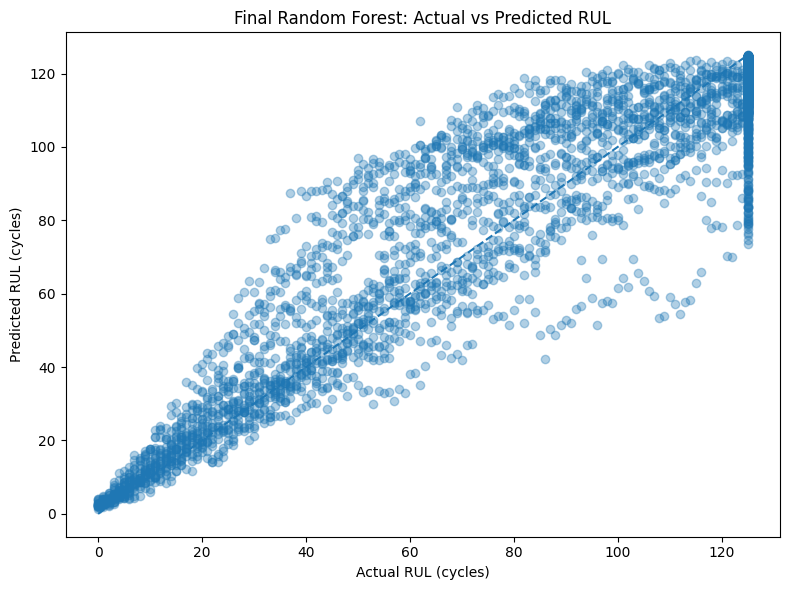

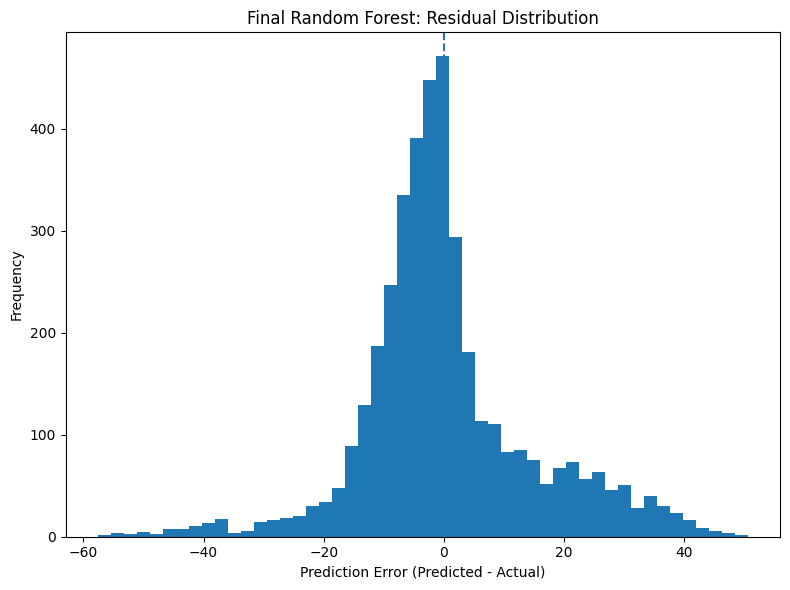

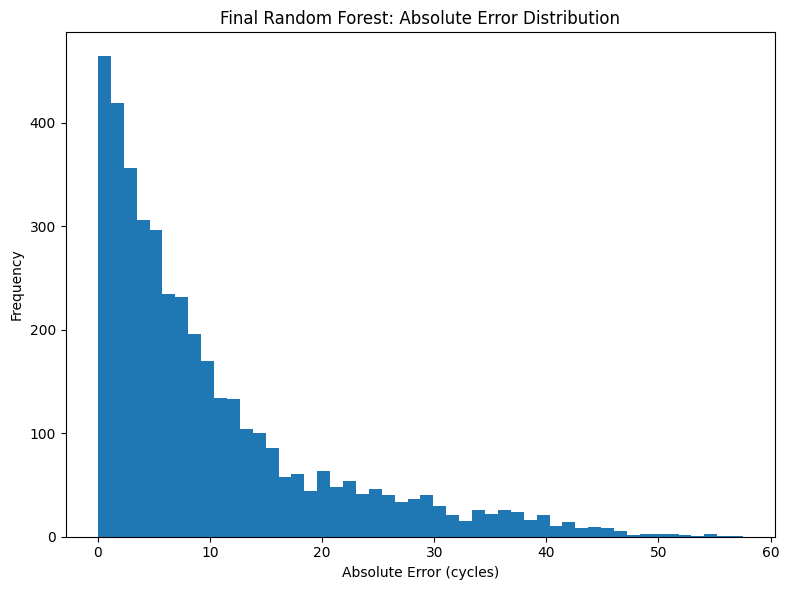

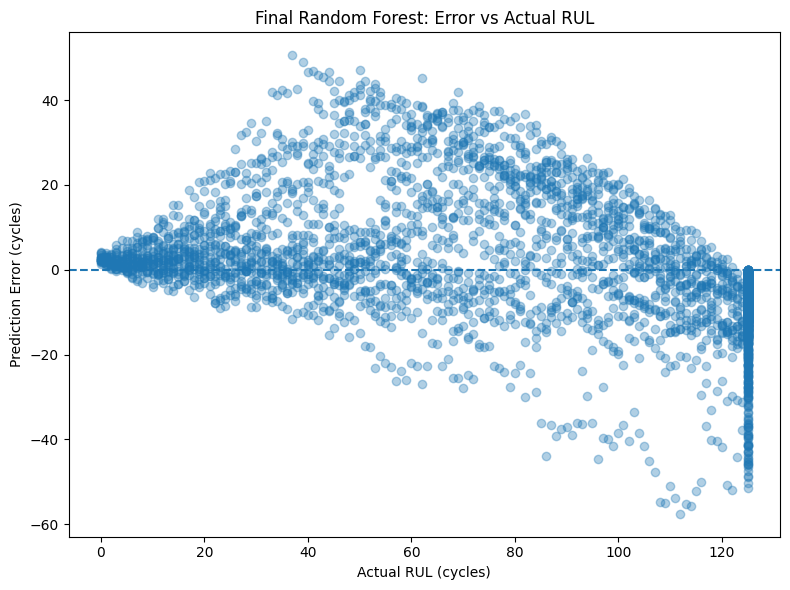

In [112]:
# FINAL HOLDOUT PREDICTION DIAGNOSTICS

import matplotlib.pyplot as plt
import numpy as np

actual = np.asarray(y_holdout)
predicted = np.asarray(holdout_predictions)

errors = predicted - actual
absolute_errors = np.abs(errors)

# ------------------------------------------------------------
# 1. Actual vs Predicted RUL
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(actual, predicted, alpha=0.35)

min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("Final Random Forest: Actual vs Predicted RUL")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Residual distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=50)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("Final Random Forest: Residual Distribution")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Absolute error distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.hist(absolute_errors, bins=50)

plt.xlabel("Absolute Error (cycles)")
plt.ylabel("Frequency")
plt.title("Final Random Forest: Absolute Error Distribution")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Error vs Actual RUL
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    actual,
    errors,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Prediction Error (cycles)")
plt.title("Final Random Forest: Error vs Actual RUL")

plt.tight_layout()
plt.show()

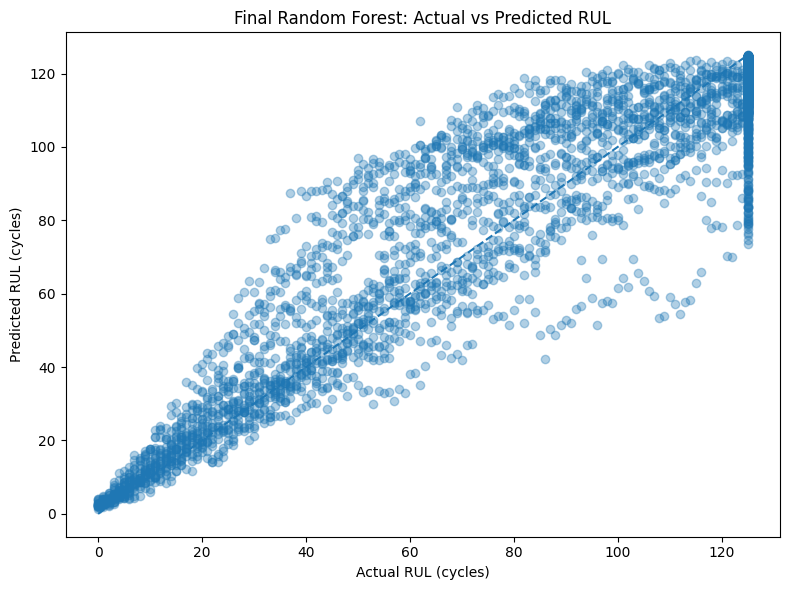

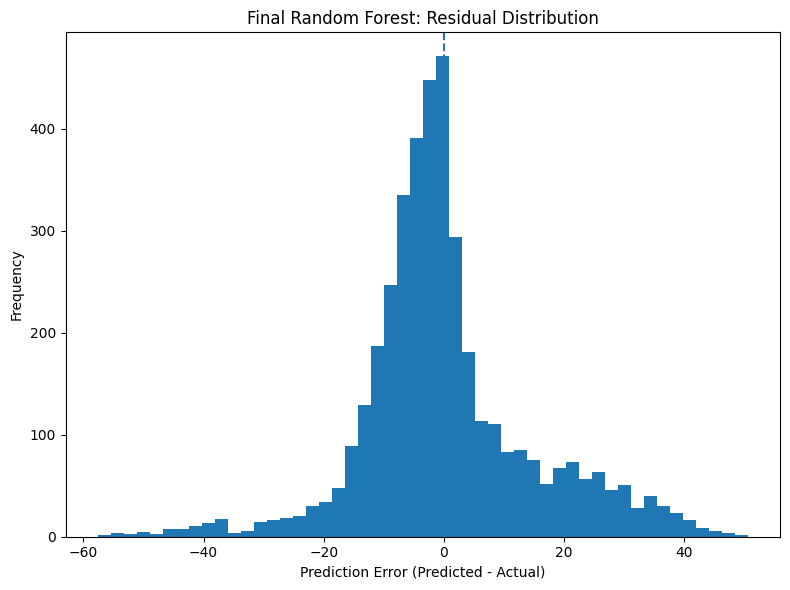

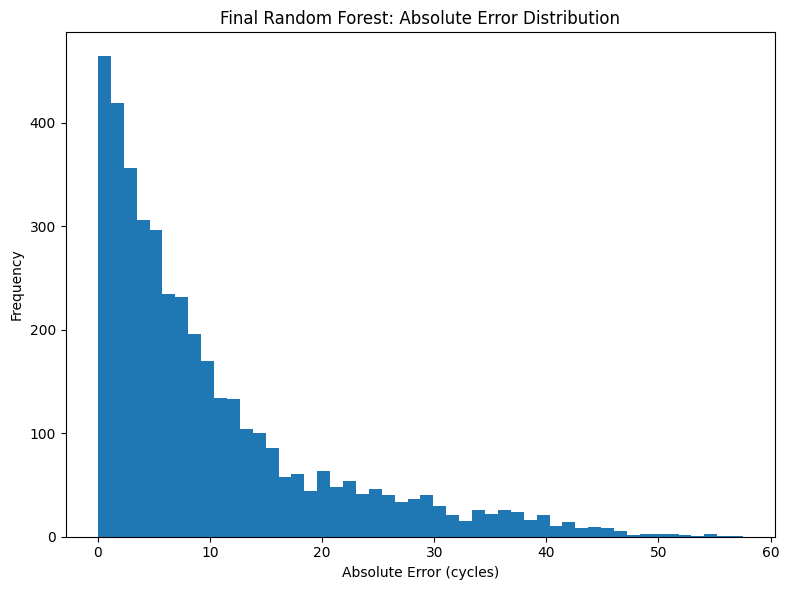

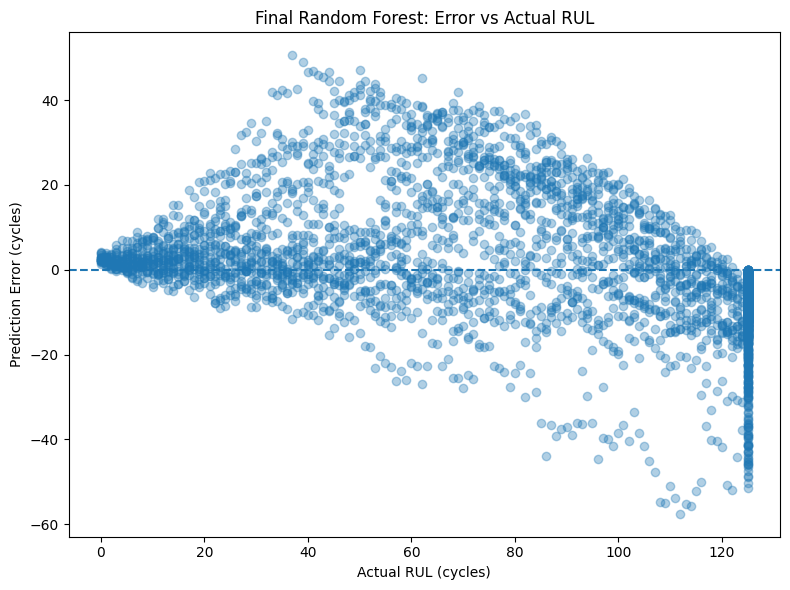

All four final diagnostic plots saved successfully.


In [113]:
# SAVE FINAL MODEL DIAGNOSTIC PLOTS

import matplotlib.pyplot as plt
import numpy as np

actual = np.asarray(y_holdout)
predicted = np.asarray(holdout_predictions)

errors = predicted - actual
absolute_errors = np.abs(errors)

# ------------------------------------------------------------
# 1. Actual vs Predicted RUL
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(actual, predicted, alpha=0.35)

min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("Final Random Forest: Actual vs Predicted RUL")

plt.tight_layout()
plt.savefig("final_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()


# ------------------------------------------------------------
# 2. Residual Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=50)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("Final Random Forest: Residual Distribution")

plt.tight_layout()
plt.savefig("final_residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()


# ------------------------------------------------------------
# 3. Absolute Error Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.hist(absolute_errors, bins=50)

plt.xlabel("Absolute Error (cycles)")
plt.ylabel("Frequency")
plt.title("Final Random Forest: Absolute Error Distribution")

plt.tight_layout()
plt.savefig("final_absolute_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()


# ------------------------------------------------------------
# 4. Error vs Actual RUL
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    actual,
    errors,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Prediction Error (cycles)")
plt.title("Final Random Forest: Error vs Actual RUL")

plt.tight_layout()
plt.savefig("final_error_vs_rul.png", dpi=300, bbox_inches="tight")
plt.show()

plt.close()


print("All four final diagnostic plots saved successfully.")

In [114]:
# FINAL MODEL FOR OFFICIAL NASA TEST EVALUATION

X_all_train = train_processed[
    feature_columns
].copy()

y_all_train = train_processed[
    target_column
].copy()

y_all_train_raw = train_processed[
    "RUL_raw"
].copy()

official_scaler = StandardScaler()

X_all_train_scaled = official_scaler.fit_transform(
    X_all_train
)

X_official_test_scaled = official_scaler.transform(
    X_official_test
)

official_rf = RandomForestRegressor(
    **rf_random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

print("Training final Random Forest on ALL NASA FD001 training engines...")

official_rf.fit(
    X_all_train_scaled,
    y_all_train
)

print("Official-test model training completed.")


Training final Random Forest on ALL NASA FD001 training engines...
Official-test model training completed.


In [115]:
# OFFICIAL NASA FD001 TEST RESULTS

official_test_predictions = official_rf.predict(
    X_official_test_scaled
)

# Primary metrics: capped RUL, matching the training target.
official_test_mae = mean_absolute_error(
    y_official_test,
    official_test_predictions
)

official_test_rmse = mean_squared_error(
    y_official_test,
    official_test_predictions
) ** 0.5

official_test_r2 = r2_score(
    y_official_test,
    official_test_predictions
)

# Supplementary metrics against the original uncapped RUL.
# This is reported separately because the model was trained on
# the capped target.
official_test_raw_mae = mean_absolute_error(
    y_official_test_raw,
    official_test_predictions
)

official_test_raw_rmse = mean_squared_error(
    y_official_test_raw,
    official_test_predictions
) ** 0.5

official_test_raw_r2 = r2_score(
    y_official_test_raw,
    official_test_predictions
)

print("=" * 70)
print("OFFICIAL NASA CMAPSS FD001 TEST RESULTS")
print("=" * 70)

print("Primary evaluation (RUL capped at 125):")
print(f"MAE:  {official_test_mae:.2f} cycles")
print(f"RMSE: {official_test_rmse:.2f} cycles")
print(f"R²:   {official_test_r2:.4f}")

print("\nSupplementary evaluation (original uncapped RUL):")
print(f"MAE:  {official_test_raw_mae:.2f} cycles")
print(f"RMSE: {official_test_raw_rmse:.2f} cycles")
print(f"R²:   {official_test_raw_r2:.4f}")


OFFICIAL NASA CMAPSS FD001 TEST RESULTS
Primary evaluation (RUL capped at 125):
MAE:  10.40 cycles
RMSE: 15.28 cycles
R²:   0.6930

Supplementary evaluation (original uncapped RUL):
MAE:  42.72 cycles
RMSE: 57.86 cycles
R²:   0.0375


In [ ]:
# TRUE OFFICIAL NASA CMAPSS FD001 BENCHMARK
# (one prediction per engine, at its last observed cycle -- n=100,
#  matches RUL_FD001.txt directly, no per-row reconstruction)

test_last_cycle_rows = (
    test_processed
    .sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_official_test_last_cycle = test_last_cycle_rows[feature_columns]
X_official_test_last_cycle_scaled = official_scaler.transform(X_official_test_last_cycle)

# ground truth, in engine-ID order, straight from RUL_FD001.txt -- no reconstruction
y_official_test_last_cycle = official_rul["RUL_at_last_cycle"].to_numpy()

official_test_predictions_last_cycle = official_rf.predict(X_official_test_last_cycle_scaled)

official_test_mae_last_cycle = mean_absolute_error(
    y_official_test_last_cycle, official_test_predictions_last_cycle
)
official_test_rmse_last_cycle = mean_squared_error(
    y_official_test_last_cycle, official_test_predictions_last_cycle
) ** 0.5
official_test_r2_last_cycle = r2_score(
    y_official_test_last_cycle, official_test_predictions_last_cycle
)

print("=" * 70)
print("TRUE OFFICIAL CMAPSS BENCHMARK (last cycle per engine, n=100)")
print("=" * 70)
print(f"MAE:  {official_test_mae_last_cycle:.2f} cycles")
print(f"RMSE: {official_test_rmse_last_cycle:.2f} cycles")
print(f"R²:   {official_test_r2_last_cycle:.4f}")


In [116]:
# ============================================================
# OFFICIAL TEST PREDICTION DIAGNOSTICS
# ============================================================

official_test_error_df = pd.DataFrame({
    "unit_id": test_processed["unit_id"].values,
    "cycle": test_processed["cycle"].values,
    "actual_RUL_raw": y_official_test_raw.values,
    "actual_RUL_capped": y_official_test.values,
    "predicted_RUL": official_test_predictions
})

official_test_error_df["error"] = (
    official_test_error_df["predicted_RUL"]
    - official_test_error_df["actual_RUL_capped"]
)

official_test_error_df["absolute_error"] = (
    official_test_error_df["error"].abs()
)

official_test_error_df["RUL_range"] = pd.cut(
    official_test_error_df["actual_RUL_capped"],
    bins=[-1, 50, 100, 125],
    labels=["0-50", "51-100", "101-125"]
)

official_test_range_analysis = (
    official_test_error_df
    .groupby("RUL_range", observed=False)
    .agg(
        count=("actual_RUL_capped", "size"),
        mean_actual_RUL=("actual_RUL_capped", "mean"),
        mean_predicted_RUL=("predicted_RUL", "mean"),
        MAE=("absolute_error", "mean"),
        mean_error=("error", "mean")
    )
    .reset_index()
)

print("Official NASA test error analysis by capped RUL range:")
display(official_test_range_analysis)


Official NASA test error analysis by capped RUL range:


,RUL_range,count,mean_actual_RUL,mean_predicted_RUL,MAE,mean_error
0,0-50,886,33.738149,49.670177,17.181114,15.932028
1,51-100,2308,78.304593,90.761179,16.287079,12.456586
2,101-125,9902,122.782771,115.303706,8.421403,-7.479065


In [117]:
# ============================================================
# OFFICIAL TEST FEATURE IMPORTANCE
# ============================================================

official_feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": official_rf.feature_importances_
})

official_feature_importance = (
    official_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features used by the final official-test model:")
display(official_feature_importance.head(20))


Top 20 features used by the final official-test model:


,feature,importance
0,sensor15_rolling_mean,0.091864
1,sensor4_rolling_mean,0.089087
2,cycle,0.081518
3,sensor11_rolling_mean,0.077756
4,sensor12_rolling_mean,0.075642
5,sensor17_rolling_mean,0.059117
6,sensor7_rolling_mean,0.055914
7,sensor3_rolling_mean,0.055903
8,sensor2_rolling_mean,0.044541
9,sensor21_rolling_mean,0.037169


In [118]:
# ============================================================
# OFFICIAL TEST RESULTS SUMMARY
# ============================================================

official_test_summary = pd.DataFrame({
    "Model": ["Random Forest"],
    "Official_Test_MAE_Capped_125": [official_test_mae],
    "Official_Test_RMSE_Capped_125": [official_test_rmse],
    "Official_Test_R2_Capped_125": [official_test_r2],
    "Official_Test_MAE_Raw": [official_test_raw_mae],
    "Official_Test_RMSE_Raw": [official_test_raw_rmse],
    "Official_Test_R2_Raw": [official_test_raw_r2],
    "Official_Test_MAE_LastCycle_n100": [official_test_mae_last_cycle],
    "Official_Test_RMSE_LastCycle_n100": [official_test_rmse_last_cycle],
    "Official_Test_R2_LastCycle_n100": [official_test_r2_last_cycle]
})

print("FINAL OFFICIAL NASA CMAPSS FD001 TEST SUMMARY")
display(official_test_summary.round(4))

print("\nImportant:")
print("- Model selection used the development-engine temporal CV.")
print("- The official NASA test set was not used for hyperparameter tuning.")
print("- The final Random Forest was retrained on all labeled training engines.")
print("- The primary test metrics use RUL capped at 125 cycles.")


FINAL OFFICIAL NASA CMAPSS FD001 TEST SUMMARY


,Model,Official_Test_MAE_Capped_125,Official_Test_RMSE_Capped_125,Official_Test_R2_Capped_125,Official_Test_MAE_Raw,Official_Test_RMSE_Raw,Official_Test_R2_Raw
0,Random Forest,10.4003,15.2813,0.693,42.7189,57.8627,0.0375



Important:
- Model selection used the development-engine temporal CV.
- The official NASA test set was not used for hyperparameter tuning.
- The final Random Forest was retrained on all labeled training engines.
- The primary test metrics use RUL capped at 125 cycles.


In [120]:
# ============================================================
# DEVELOPMENT / MODEL-SELECTION RESULTS SUMMARY
# ============================================================

baseline_frames = []

# Random Forest
# Use full_feature_results because it contains R2.
if "full_feature_results" in globals() and full_feature_results:
    baseline_rf = (
        pd.DataFrame(full_feature_results)
        .assign(Model="Random Forest")
        .groupby("Model")
        .agg(
            **{
                "Baseline Mean MAE": ("MAE", "mean"),
                "Baseline Mean RMSE": ("RMSE", "mean"),
                "Baseline Mean R2": ("R2", "mean")
            }
        )
        .reset_index()
    )
    baseline_frames.append(baseline_rf)

elif "baseline_results_df" in globals():
    # Fallback if full_feature_results is unavailable.
    baseline_rf = (
        baseline_results_df
        .assign(Model="Random Forest")
        .groupby("Model")
        .agg(
            **{
                "Baseline Mean MAE": ("MAE", "mean"),
                "Baseline Mean RMSE": ("RMSE", "mean")
            }
        )
        .reset_index()
    )

    # R2 isn't available in this older result dataframe.
    baseline_rf["Baseline Mean R2"] = np.nan
    baseline_frames.append(baseline_rf)


# XGBoost
if "xgb_results" in globals():
    baseline_xgb = (
        pd.DataFrame(xgb_results)
        .assign(Model="XGBoost")
        .groupby("Model")
        .agg(
            **{
                "Baseline Mean MAE": ("MAE", "mean"),
                "Baseline Mean RMSE": ("RMSE", "mean"),
                "Baseline Mean R2": ("R2", "mean")
            }
        )
        .reset_index()
    )
    baseline_frames.append(baseline_xgb)


# Gradient Boosting
if "gb_results" in globals():
    baseline_gb = (
        pd.DataFrame(gb_results)
        .assign(Model="Gradient Boosting")
        .groupby("Model")
        .agg(
            **{
                "Baseline Mean MAE": ("MAE", "mean"),
                "Baseline Mean RMSE": ("RMSE", "mean"),
                "Baseline Mean R2": ("R2", "mean")
            }
        )
        .reset_index()
    )
    baseline_frames.append(baseline_gb)


# Combine baseline results
baseline_summary = (
    pd.concat(baseline_frames, ignore_index=True)
    if baseline_frames
    else pd.DataFrame()
)


# Tuned model results
tuned_summary = (
    tuned_fold_results_df
    .groupby("model")
    .agg(
        Tuned_Mean_MAE=("MAE", "mean"),
        Tuned_Mean_RMSE=("RMSE", "mean"),
        Tuned_Mean_R2=("R2", "mean")
    )
    .reset_index()
    .rename(columns={"model": "Model"})
)


# Display development results
print("DEVELOPMENT / TEMPORAL-CV RESULTS")

display(
    baseline_summary
    .merge(tuned_summary, on="Model", how="outer")
    .round(4)
)


# Display official NASA FD001 test results
print("\nOFFICIAL NASA TEST RESULTS")

display(
    official_test_summary.round(4)
)

DEVELOPMENT / TEMPORAL-CV RESULTS


,Model,Baseline Mean MAE,Baseline Mean RMSE,Baseline Mean R2,Tuned_Mean_MAE,Tuned_Mean_RMSE,Tuned_Mean_R2
0,Gradient Boosting,14.1910,19.6075,0.7662,14.4673,19.4813,0.7713
1,Random Forest,14.1334,19.9917,0.7537,14.3558,18.8871,0.7837
2,XGBoost,14.3319,20.0823,0.7535,14.4365,19.8526,0.7602



OFFICIAL NASA TEST RESULTS


,Model,Official_Test_MAE_Capped_125,Official_Test_RMSE_Capped_125,Official_Test_R2_Capped_125,Official_Test_MAE_Raw,Official_Test_RMSE_Raw,Official_Test_R2_Raw
0,Random Forest,10.4003,15.2813,0.693,42.7189,57.8627,0.0375
